This notebook demonstrates a simple linear regression analysis using R to model Salary based on Years of Experience. It includes annotated regression plots and detailed diagnostic checks (residuals, normality, and influence metrics).

In [1]:
dataset <- read.csv("regression_data.csv")
head(dataset)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


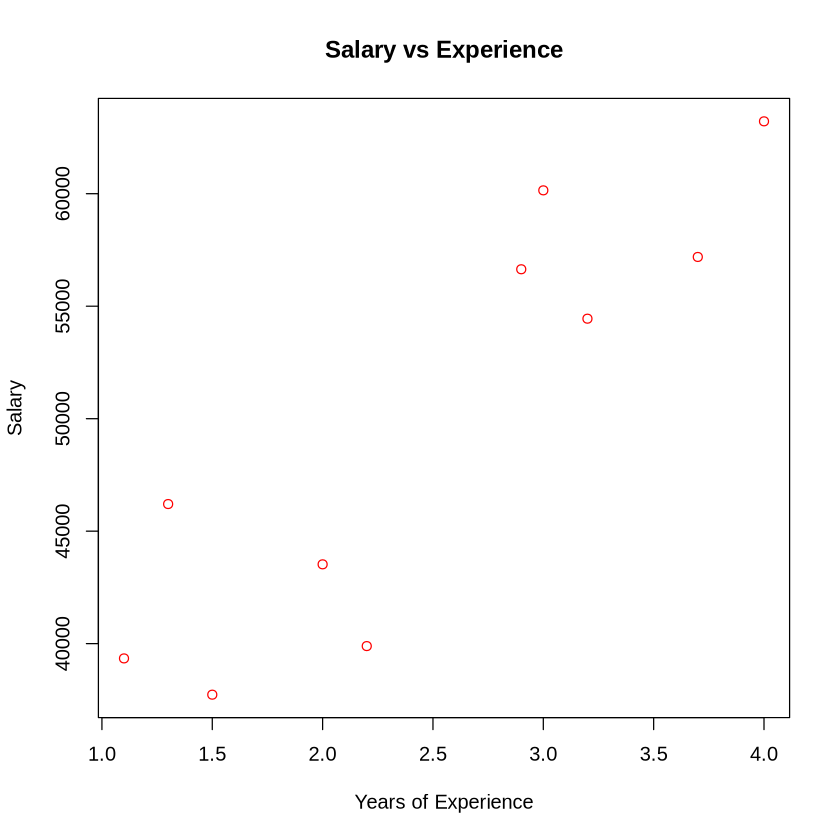

In [2]:
plot(
  dataset$YearsExperience,
  dataset$Salary,
  col = "red",
  main = "Salary vs Experience",
  xlab = "Years of Experience",
  ylab = "Salary"
)

In [3]:
model <- lm(Salary ~ YearsExperience, data = dataset)

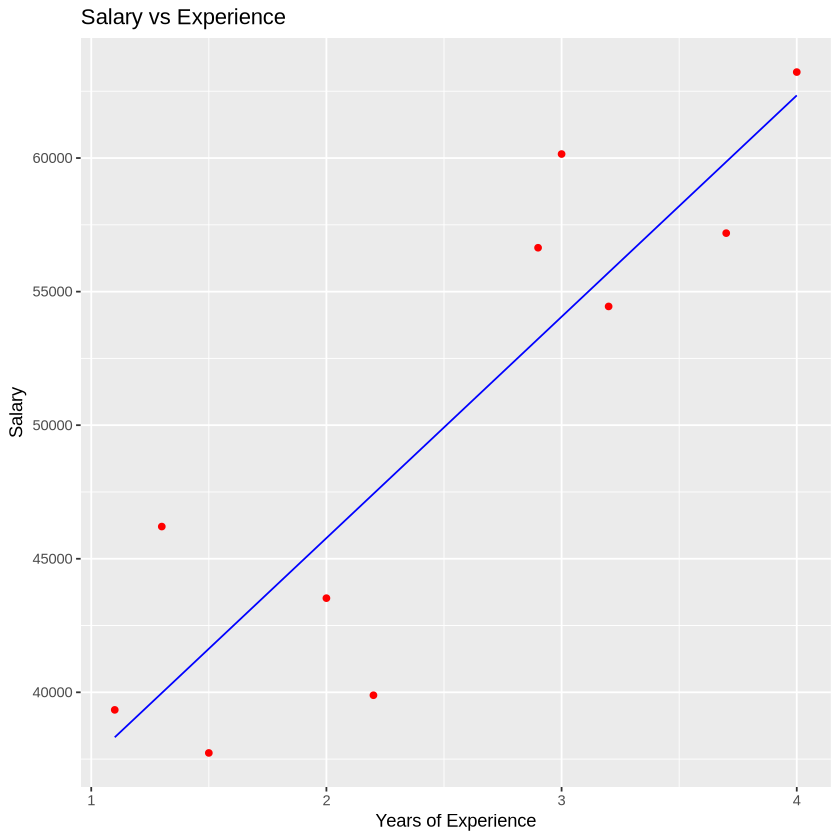

In [4]:
library(ggplot2)

ggplot(dataset, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "red") +
  geom_line(
    aes(y = predict(model, newdata = dataset)),
    color = "blue"
  ) +
  ggtitle("Salary vs Experience") +
  xlab("Years of Experience") +
  ylab("Salary")

In [5]:
summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407


In [ ]:
fitted_vals <- fitted(model)
residuals <- residuals(model)
r_squared <- summary(model)$r.squared
adj_r_squared <- summary(model)$adj.r.squared
coefs <- coef(model)
rmse <- sqrt(mean(residuals^2))

pred_grid <- data.frame(
  YearsExperience = seq(min(dataset$YearsExperience), max(dataset$YearsExperience), length.out = 100)
)
pred_grid$fit <- predict(model, newdata = pred_grid)
pred_grid$se <- predict(model, newdata = pred_grid, se.fit = TRUE)$se.fit
pred_grid$lower <- pred_grid$fit - qt(0.975, df = model$df.residual) * pred_grid$se
pred_grid$upper <- pred_grid$fit + qt(0.975, df = model$df.residual) * pred_grid$se

equation <- sprintf("Salary = %.0f + %.0f * YearsExperience", coefs[1], coefs[2])
annotation <- sprintf("%s\nR² = %.4f\nAdj. R² = %.4f\nRMSE = %.0f", equation, r_squared, adj_r_squared, rmse)

ggplot(dataset, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "red", alpha = 0.8) +
  geom_ribbon(data = pred_grid, aes(x = YearsExperience, ymin = lower, ymax = upper),
              inherit.aes = FALSE, fill = "blue", alpha = 0.15) +
  geom_line(data = pred_grid, aes(x = YearsExperience, y = fit), color = "blue", linewidth = 1) +
  annotate("label", x = min(dataset$YearsExperience), y = max(dataset$Salary),
           label = annotation, hjust = 0, vjust = 1, fill = "wheat", alpha = 0.85) +
  ggtitle("Salary vs Experience — Annotated Regression") +
  xlab("Years of Experience") +
  ylab("Salary")

In [ ]:
png("regression_diagnostics_r.png", width = 1000, height = 800)
par(mfrow = c(2, 2))
plot(fitted_vals, residuals, main = "Residuals vs Fitted", xlab = "Fitted values", ylab = "Residuals", pch = 19, col = "steelblue")
abline(h = 0, lty = 2, col = "gray")
qqnorm(residuals, main = "Normal Q-Q Plot", pch = 19, col = "steelblue")
qqline(residuals, col = "red")
plot(fitted_vals, sqrt(abs(rstandard(model))), main = "Scale-Location", xlab = "Fitted values", ylab = "√|Standardized residuals|", pch = 19, col = "darkorange")
hist(residuals, main = "Residual Distribution", xlab = "Residual", col = "seagreen", border = "white")
dev.off()

cat("Residual mean:", round(mean(residuals), 2), "\n")
cat("Residual std:", round(sd(residuals), 2), "\n")
cat("Max |residual|:", round(max(abs(residuals)), 2), "\n")
cat("Max Cook's distance:", round(max(cooks.distance(model)), 4), "\n")